<a href="https://colab.research.google.com/github/kitlapp/Telco_ML/blob/katerina/Regression_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Libraries

In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,OneHotEncoder

# Linear regression
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf
import statsmodels.api as sm
# Regression metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Regularization - Ridge and Lasso regression (linear regressions)
from sklearn.linear_model import Ridge, RidgeCV, ElasticNet
from sklearn.linear_model import Lasso, LassoCV,ElasticNetCV
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor
#
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
#
import shap
#
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
#
#
from sklearn import set_config #this is so that all output from transform keeps the column names
set_config(transform_output="pandas")
#
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set parameters like font sizes for all plots
sns.set_context("paper", rc={"font.size":15,
                             "axes.titlesize":15,
                             "axes.labelsize":15})
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

%matplotlib inline
#
# Set pandas display option to show up to 100 columns when printing a DataFrame
pd.set_option('display.max_columns', 100)


Read the file

#Load File from drive. Only used partially the Github file as it had already OHE

In [77]:
#Load file from github public repository
# Read the dataset to a DataFrame
url = "https://github.com/kitlapp/Telco_ML/raw/main/ml_ready_dataset_nodummies.parquet"
df = pd.read_parquet(url, engine="pyarrow")
df.head()

,Is_Male,Is_Senior,Is_Married,Has_Dependents,Tenure,Has_PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,Is_PaperlessBilling,PaymentMethod,Total_Charges,Is_Churned,Avg_Monthly_Charge
0,False,False,True,False,1,False,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,True,Electronic check,29.85,False,29.85
1,True,False,False,False,34,True,No,DSL,Yes,No,Yes,No,No,No,One year,False,Mailed check,1889.50,False,55.57
2,True,False,False,False,2,True,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,True,Mailed check,108.15,True,54.08
3,True,False,False,False,45,False,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,False,Bank transfer (automatic),1840.75,False,40.91
4,False,False,False,False,2,True,No,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Electronic check,151.65,True,75.82


In [78]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 7043
Number of Columns: 20


In [35]:
df.columns.to_list()

['Is_Male',
 'Is_Senior',
 'Is_Married',
 'Has_Dependents',
 'Tenure',
 'Has_PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'Is_PaperlessBilling',
 'PaymentMethod',
 'Total_Charges',
 'Is_Churned',
 'Avg_Monthly_Charge']

In [36]:
#Create a dictinary with new features to incorporate later in the sequence of ML steps
df_f = df.copy()

# Feature Engineering

## Household Type

In [37]:
#Inspired by the Titanic Dataset we can what driver a family can be
# np.select to create a categorical label based on multiple conditions
conditions = [
    (df_f['Is_Married'] == True) & (df_f['Has_Dependents'] == True),  # Family
    (df_f['Is_Married'] == True) & (df_f['Has_Dependents'] == False), # Couple
    (df_f['Is_Married'] == False) & (df_f['Has_Dependents'] == True), # Single Parent
    (df_f['Is_Married'] == False) & (df_f['Has_Dependents'] == False) # Single Adult
]
choices = ['Family', 'Couple', 'Single Parent', 'Single Adult']

df_f['Household_Type'] = np.select(conditions, choices, default='Unknown')


In [38]:
#Sanity Check
df_f.Household_Type.value_counts()

,count
Household_Type,
Single Adult,3280
Family,1749
Couple,1653
Single Parent,361


## Total Additional Services Usage

In [39]:
## Find if the additional services as a total play a role
# List the columns that represent additional services
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'MultipleLines']

# Count how many 'Yes' values exist across these columns for each row
df_f['Additional_Services'] = (df_f[service_cols] == 'Yes').sum(axis=1)


We will keep the individual OHE features to capture specific product preferences, together with the Service_Count to see with an ordinal value the depth of each customers engagement contranct. Using hte company for full services rather than only basic Internet and Phone servcies

**What shall we try to predict with Regression**
Avg_Monthly_Charges : the engineered field which accounts for the total dollars that somebody is paying, regardless of the contract. So it could be more than the contract if they have gone to overage.
**So we do not try to see the contract to be sold, but rathere OPERATIONALLY what the customer spend will be irrespective to contract**

#Correlated Variables to drop
From the correlation analysis we have:  
Avg_monthly charges is correlated as below:  
Correlation with Tenure: 0.249  
Correlation with Total_Charges: 0.651  
Correlation with Monthly_Charges: 0.994  

We drop:

**Monthly_Charges**: correlation is $0.994$, leakage of target in the features.   (Already dropped from EDA. )   
**Total_Charges**:correlation is ($0.651$), not so big, but still avg_total_charges is derived from it.  
**Is_Churned**: this is info not acquired yet. It is in the future

In [40]:
df.drop(['Total_Charges', 'Is_Churned'], axis=1, inplace=True)
df_f.drop(['Total_Charges', 'Is_Churned'], axis=1, inplace=True)

#First Approach: DataSet with No Additional Features

## Train Test Split

In [41]:
#define X and y
y = df['Avg_Monthly_Charge']
X = df.drop('Avg_Monthly_Charge',axis = 1)
print ("X dimensions: ", X.shape)
print ("y dimensions: ", y.shape)

X dimensions:  (7043, 17)
y dimensions:  (7043,)


In [42]:
# Use the train_test_split() function from sklearn. Use 30% of your data for the test set. Use stratification if needed.
# Set random_state=42 (for reproducibility). Print the dimensionality (shape) of X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.30,
                                                    random_state=42)

print('Shape of X_train and y_train: ', X_train.shape, y_train.shape)
print('Shape of X_test and y_test: ',   X_test.shape,  y_test.shape)

Shape of X_train and y_train:  (4930, 17) (4930,)
Shape of X_test and y_test:  (2113, 17) (2113,)


## Create a function to evaluate the Regression Scores

In [43]:
def fit_and_evaluate_regression(pred, name):
    print('------------- {} -------------'.format(name))
    print('R^2 score - ', r2_score(y_test, pred))
    print('MAE score - ', mean_absolute_error(y_test, pred))

#ColumnTransformer: OHE and StandartScaler with numerical and categorical features

Since it is very difficult to make sure that ohe will work both for the train and the test without breaking the ML algorithms, since it is done after train-test split,  we will use the ColumnTrnansformer to take care of Scaling for the Numerical and OneHot encoding for the categorical.

In [45]:
#Code provided fromteh lectures
#
# Instead of 6 columns being with "No Internet" flags, we just use the main InternetService category
categorical_features = X_train.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

cat_steps = [('OHE', OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False))]
pipe_cat = Pipeline(cat_steps)
num_steps = [('scaler', StandardScaler())]
pipe_num = Pipeline(num_steps)

one_pipe = ColumnTransformer(
    transformers=[
        ('numbers', pipe_num, numeric_features),
        ('categories',pipe_cat,categorical_features)
    ])

In [46]:
#fit and transform the train data set. transform the test
X_train_ohe = one_pipe.fit_transform(X_train)
X_test_ohe = one_pipe.transform(X_test)

In [47]:
X_train_ohe.head()

,numbers__Tenure,categories__Is_Male_True,categories__Is_Senior_True,categories__Is_Married_True,categories__Has_Dependents_True,categories__Has_PhoneService_True,categories__MultipleLines_No phone service,categories__MultipleLines_Yes,categories__InternetService_Fiber optic,categories__InternetService_No,categories__OnlineSecurity_No internet service,categories__OnlineSecurity_Yes,categories__OnlineBackup_No internet service,categories__OnlineBackup_Yes,categories__DeviceProtection_No internet service,categories__DeviceProtection_Yes,categories__TechSupport_No internet service,categories__TechSupport_Yes,categories__StreamingTV_No internet service,categories__StreamingTV_Yes,categories__StreamingMovies_No internet service,categories__StreamingMovies_Yes,categories__Contract_One year,categories__Contract_Two year,categories__Is_PaperlessBilling_True,categories__PaymentMethod_Credit card (automatic),categories__PaymentMethod_Electronic check,categories__PaymentMethod_Mailed check
1695,0.881078,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1095,-1.284263,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3889,-0.793997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3667,-0.344587,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2902,-1.079985,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [48]:
X_test_ohe.head()

,numbers__Tenure,categories__Is_Male_True,categories__Is_Senior_True,categories__Is_Married_True,categories__Has_Dependents_True,categories__Has_PhoneService_True,categories__MultipleLines_No phone service,categories__MultipleLines_Yes,categories__InternetService_Fiber optic,categories__InternetService_No,categories__OnlineSecurity_No internet service,categories__OnlineSecurity_Yes,categories__OnlineBackup_No internet service,categories__OnlineBackup_Yes,categories__DeviceProtection_No internet service,categories__DeviceProtection_Yes,categories__TechSupport_No internet service,categories__TechSupport_Yes,categories__StreamingTV_No internet service,categories__StreamingTV_Yes,categories__StreamingMovies_No internet service,categories__StreamingMovies_Yes,categories__Contract_One year,categories__Contract_Two year,categories__Is_PaperlessBilling_True,categories__PaymentMethod_Credit card (automatic),categories__PaymentMethod_Electronic check,categories__PaymentMethod_Mailed check
185,-1.284263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2715,0.349957,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3825,0.799367,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1807,-1.284263,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
132,1.412199,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [49]:
# We need to clean the column names after Column Transformation to make them more easily readable
X_train_ohe.columns = (X_train_ohe.columns
                       .str.replace('numbers__', '', regex=False)
                       .str.replace('categories__', '', regex=False))

#Same for the X_test_ohe
X_test_ohe.columns = (X_test_ohe.columns
                      .str.replace('numbers__', '', regex=False)
                      .str.replace('categories__', '', regex=False))

# Check the results
X_train_ohe.head()

,Tenure,Is_Male_True,Is_Senior_True,Is_Married_True,Has_Dependents_True,Has_PhoneService_True,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,Is_PaperlessBilling_True,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1695,0.881078,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1095,-1.284263,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3889,-0.793997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3667,-0.344587,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2902,-1.079985,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Rename Features in Train/Test for better understanding

In [50]:
mapping = {
     'Is_Male_True': 'Is_Male',
     'Is_Senior_True': 'Is_Senior',
     'Is_Married_True': 'Is_Married',
     'Has_Dependents_True': 'Has_Dependents',
     'Has_PhoneService_True': 'Has_PhoneService',
     # One-hot / multi-category features
    'OnlineSecurity_Yes': 'Has_OnlineSecurity_Yes',
    'OnlineSecurity_No internet service': 'Has_OnlineSecurity_NoInternet',
    #'OnlineSecurity_Yes': 'Has_OnlineSecurity_Yes',

    #'OnlineBackup_No': 'Has_OnlineBackup_No',
    'OnlineBackup_No internet service': 'Has_OnlineBackup_NoInternet',
    'OnlineBackup_Yes': 'Has_OnlineBackup_Yes',

    #'DeviceProtection_No': 'Has_DeviceProtection_No',
    'DeviceProtection_No internet service': 'Has_DeviceProtection_NoInternet',
    'DeviceProtection_Yes': 'Has_DeviceProtection_Yes',

    #'TechSupport_No': 'Has_TechSupport_No',
    'TechSupport_No internet service': 'Has_TechSupport_NoInternet',
    'TechSupport_Yes': 'Has_TechSupport_Yes',

    #'StreamingTV_No': 'Has_StreamingTV_No',
    'StreamingTV_No internet service': 'Has_StreamingTV_NoInternet',
    'StreamingTV_Yes': 'Has_StreamingTV_Yes',

    #'StreamingMovies_No': 'Has_StreamingMovies_No',
    'StreamingMovies_No internet service': 'Has_StreamingMovies_NoInternet',
    'StreamingMovies_Yes': 'Has_StreamingMovies_Yes',

    #'MultipleLines_No': 'Has_MultipleLines_No',
    'MultipleLines_No phone service': 'Has_MultipleLines_NoPhone',
    'MultipleLines_Yes': 'Has_MultipleLines_Yes',

    #'InternetService_DSL': 'Is_InternetService_DSL',
    'InternetService_Fiber optic': 'Is_InternetService_FiberOptic',
    'InternetService_No': 'Is_InternetService_None',

    #'Contract_Month-to-month': 'Is_Contract_MonthToMonth',
    'Contract_One year': 'Is_Contract_OneYear',
    'Contract_Two year': 'Is_Contract_TwoYear',

    #'PaymentMethod_Bank transfer (automatic)': 'Is_PaymentMethod_BankTransfer',
    'PaymentMethod_Credit card (automatic)': 'Is_PaymentMethod_CreditCard',
    'PaymentMethod_Electronic check': 'Is_PaymentMethod_ElectronicCheck',
    'PaymentMethod_Mailed check': 'Is_PaymentMethod_MailedCheck'
}
X_train_ohe = X_train_ohe.rename(columns=mapping)
X_test_ohe = X_test_ohe.rename(columns=mapping)

In [51]:
#Sanity Check
X_train_ohe.head()

,Tenure,Is_Male,Is_Senior,Is_Married,Has_Dependents,Has_PhoneService,Has_MultipleLines_NoPhone,Has_MultipleLines_Yes,Is_InternetService_FiberOptic,Is_InternetService_None,Has_OnlineSecurity_NoInternet,Has_OnlineSecurity_Yes,Has_OnlineBackup_NoInternet,Has_OnlineBackup_Yes,Has_DeviceProtection_NoInternet,Has_DeviceProtection_Yes,Has_TechSupport_NoInternet,Has_TechSupport_Yes,Has_StreamingTV_NoInternet,Has_StreamingTV_Yes,Has_StreamingMovies_NoInternet,Has_StreamingMovies_Yes,Is_Contract_OneYear,Is_Contract_TwoYear,Is_PaperlessBilling_True,Is_PaymentMethod_CreditCard,Is_PaymentMethod_ElectronicCheck,Is_PaymentMethod_MailedCheck
1695,0.881078,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1095,-1.284263,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3889,-0.793997,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3667,-0.344587,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2902,-1.079985,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


#Correlation of OHE Features

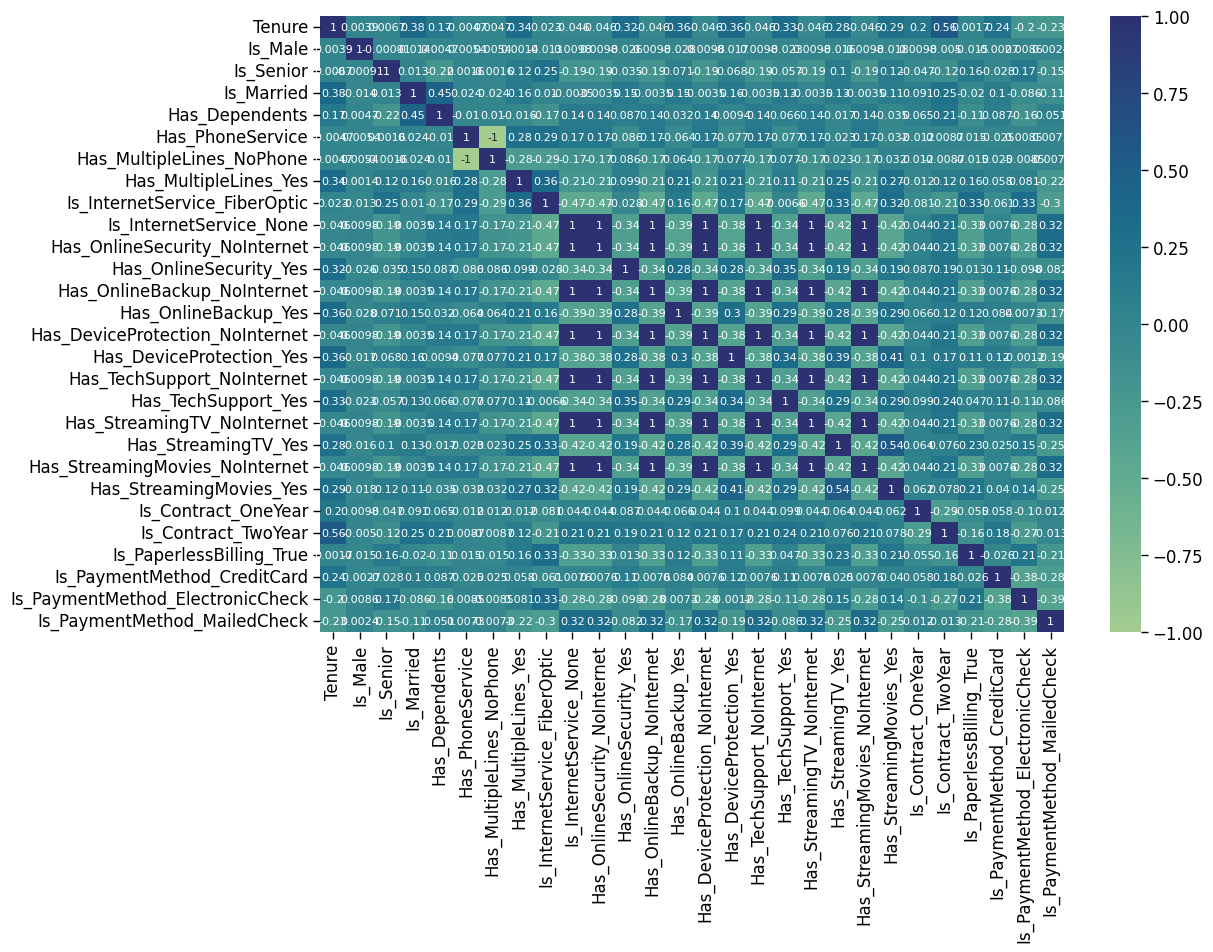

In [52]:
# Calculate the correlation matrix of X_train DataFrame using the .corr() function and
# save it in a variable called 'corr_matrix'. Then pass the corr_matrix to the sns.heatmap() function for plotting.
# Optional: you can use f, ax = plt.subplots(figsize=(12, 8))
# Optional sns.heatmap arguments : annot=True,  annot_kws={'size': 8} and cmap="Spectral_r"

corr_matrix = X_train_ohe.corr()

f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            annot_kws={'size': 8},
            cmap="crest");

We need to drop all the "No Internet" columns as they are highly correlated with the Is_InternetService_Nonw. If the model knows the person has "No Internet Service" via the InternetService_None column, it doesn't need 6 more columns telling it the same thing for every sub-feature.

This is very important for Regression Models and Multicollinearity

## Reduce Dimensionality due to extreme correlation with NoInternet and NoPhone descrition


In [53]:
#Find the columns to exclude with names "NoIntenet" or "NoPhone" from the list
# Filter the list
alllist = X_train_ohe.columns.to_list()
redundant_terms = ["NoInternet", "NoPhone"]
toclean_list = [item for item in alllist if any(term in item for term in redundant_terms)]
print(toclean_list)


['Has_MultipleLines_NoPhone', 'Has_OnlineSecurity_NoInternet', 'Has_OnlineBackup_NoInternet', 'Has_DeviceProtection_NoInternet', 'Has_TechSupport_NoInternet', 'Has_StreamingTV_NoInternet', 'Has_StreamingMovies_NoInternet']


In [54]:
X_train_ohe = X_train_ohe.drop(columns=toclean_list)
X_test_ohe = X_test_ohe.drop(columns=toclean_list)

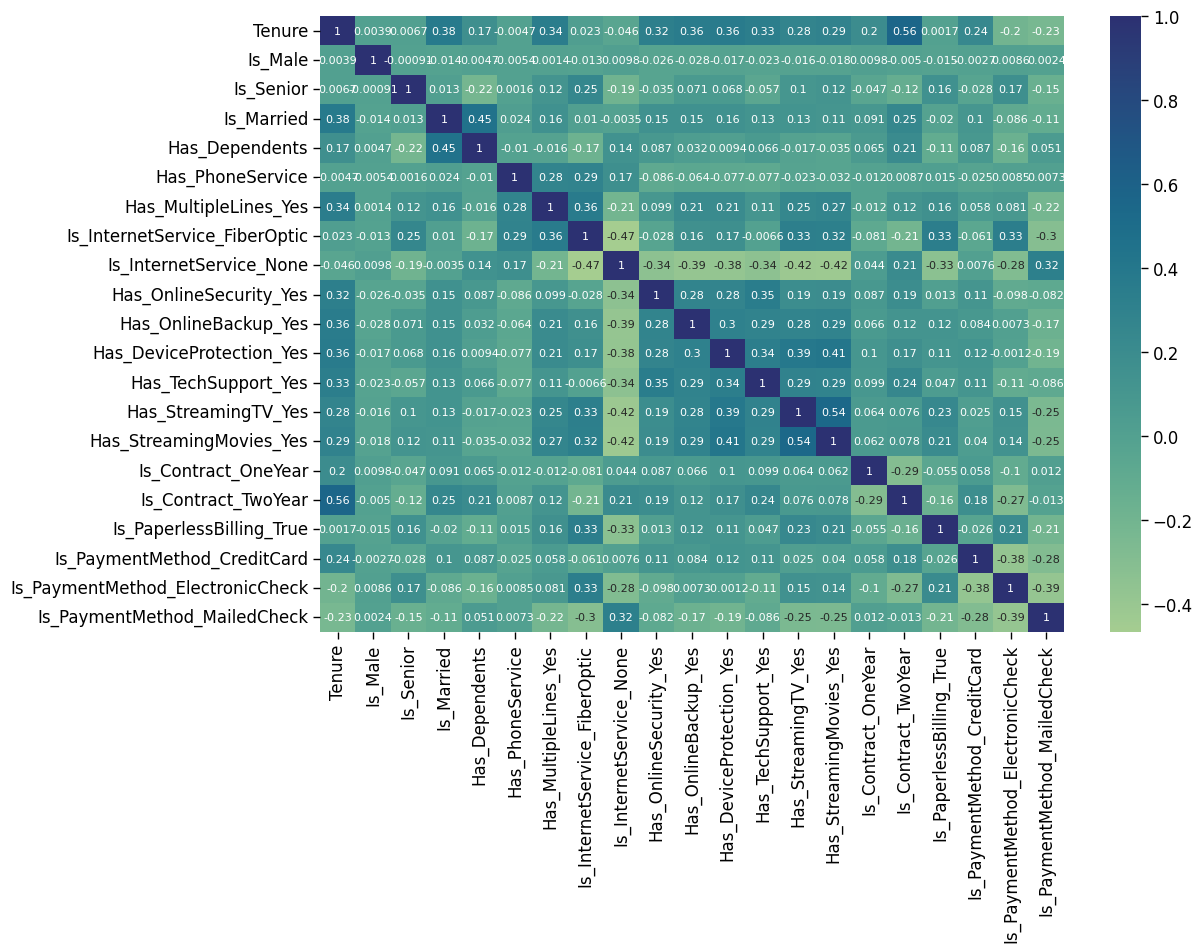

In [55]:
corr_matrix = X_train_ohe.corr()

f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            annot_kws={'size': 8},
            cmap="crest");

In [56]:
X_train_ohe.shape


(4930, 21)

The dataset seems clean now, ready for regression.

# Baseline Simple Models to check behavior

In [57]:
X_train = X_train_ohe.copy()
X_test = X_test_ohe.copy()

## Initialize a DataFrame to hold Regression results

In [84]:
# Create an empty DataFrame named 'regr_results' to store and compare evaluation results from the various regressors
regr_results = pd.DataFrame([])

In [86]:
#Linear Regression-------------------------------------------------------------

linear_regr = LinearRegression()
linear_regr.fit(X_train, y_train)
y_pred = linear_regr.predict(X_test)
#
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Linear Regression',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

# Ridge Regression------------------------------------------------------------
ridgeCV_model = RidgeCV(alphas=np.logspace(-6, 6, 13), scoring='r2', cv=10)
ridgeCV_model.fit(X_train, y_train)
optimal_alpha = ridgeCV_model.alpha_
#
ridge_regr = Ridge(alpha = optimal_alpha)
ridge_regr.fit(X_train, y_train)
y_pred = ridge_regr.predict(X_test)
#
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Ridge',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])
#Lasso Regression--------------------------------------------------------------
lassoCV_model = LassoCV(alphas=np.logspace(-6, 6, 13), cv=10, random_state=0)
lassoCV_model.fit(X_train, y_train)
optimal_alpha = lassoCV_model.alpha_
#
lasso_regr = Lasso(alpha = optimal_alpha)
lasso_regr.fit(X_train, y_train)
y_pred = lasso_regr.predict(X_test)
regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'Lasso',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])
#RandomForest Regression ------------------------------------------------------
rf  = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({'Model': 'RandomForest',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])
# KNN Regression ------------------------------------------------------------
knn = KNeighborsRegressor(n_neighbors=5) # 5 is the standard starting point
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({
                                                        'Model': 'KNN',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

# SVM Regression ------------------------------------------------------------
svr = SVR(kernel='linear', C=1.0) # Linear kernel matches your high R2 findings
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({
                                                      'Model': 'SVR',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])

# XGBoost Regression ---------------------------------------------------------
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

regr_results = pd.concat([regr_results, pd.json_normalize({
                                                      'Model': 'XGBoost',
                                                           'r2':   round(r2_score(y_test, y_pred),5),
                                                           'MAE':  round(mean_absolute_error(y_test, y_pred),5)})])


In [87]:
regr_results.sort_values(by='r2', ascending=False)

,Model,r2,MAE
0,XGBoost,0.98627,2.20687
0,Ridge,0.98465,2.09038
0,Linear Regression,0.98465,2.09045
0,Lasso,0.98464,2.08549
0,SVR,0.98451,2.07542
0,RandomForest,0.98327,2.41097
0,KNN,0.95544,4.28856


In [76]:
regr_results.sort_values(by='MAE', ascending=False)

,Model,r2,MAE
0,KNN,0.955,4.289
0,RandomForest,0.983,2.411
0,XGBoost,0.986,2.207
0,Linear Regression,0.985,2.090
0,Ridge,0.985,2.090
0,Lasso,0.985,2.085
0,SVR,0.985,2.075


MAE is a metric that shows the proximity to the predicted value. Taking under consideration that the mean is close to 65 and the median close to 70, then the MAE of 2.5 is quite good.
The R^2 is a measure of how much of the variablity in y is determined by the X values . So all models have very high values

We are going to see how algorithms behave for
**XGBoost and Ridge** for R^2 and
**SVR and Lasso** for MAE

**Tree-based "Feature Importance":** Shows how much a feature was used to split the data (e.g., "Tenure is 0.45 important"). It's always a positive number.

**Lasso "Coefficients":** show the actual weight of the feature (e.g., "Fiber Optic is +42.0").

In [81]:
y_test.describe().T

,Avg_Monthly_Charge
count,2113.000000
mean,64.593393
std,30.079894
min,0.000000
25%,36.600000
50%,70.000000
75%,89.980000
max,120.450000


## Coefficients for Lasso Ridge

### Lasso Coefficients

r2 score (coefficient of determination): 0.985
MAE : 2.085
alpha: ",optimal_alpha
Model coefficients: [ 2.07421273e-01  2.69308407e-02 -0.00000000e+00 -9.45642045e-02
 -1.49999989e-01  2.01105887e+01  5.04870885e+00  2.48938468e+01
 -2.50419954e+01  5.02442809e+00  4.88137594e+00  5.03097713e+00
  5.00043077e+00  9.71665624e+00  1.01427649e+01 -0.00000000e+00
 -2.66017702e-01  6.99562755e-03  0.00000000e+00  6.26360810e-03
 -1.27895330e-01]


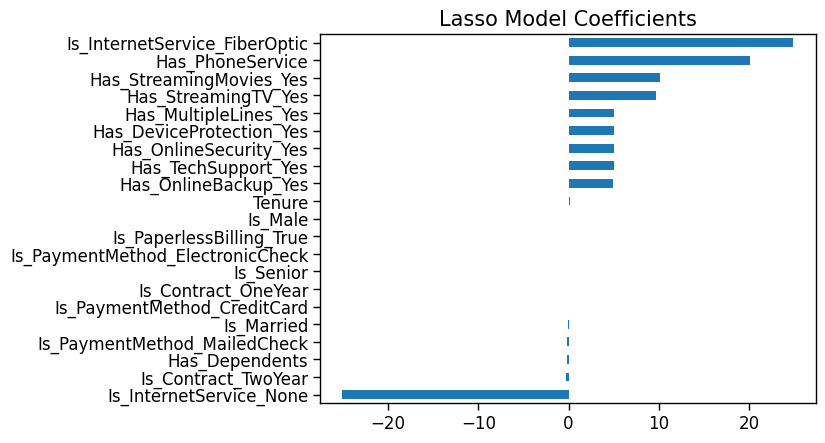

In [59]:
#Lasso Regression--------------------------------------------------------------
lassoCV_model = LassoCV(alphas=np.logspace(-6, 6, 13), cv=10, random_state=0)
lassoCV_model.fit(X_train, y_train)
optimal_alpha = lassoCV_model.alpha_
#
lasso_regr = Lasso(alpha = optimal_alpha)
lasso_regr.fit(X_train, y_train)
y_pred = lasso_regr.predict(X_test)

print('r2 score (coefficient of determination): '+str(round(r2_score(y_test, y_pred),3)))
print('MAE : ' +str(round(mean_absolute_error(y_test, y_pred),3)))
print('alpha: ",optimal_alpha')
#
print('Model coefficients:', lasso_regr.coef_)
#extract the coefficients
coef_lasso = pd.DataFrame({"var": X_train.columns,
                           "coef":lasso_regr.coef_})

coef = pd.Series(lasso_regr.coef_, X_train.columns).sort_values()
coef.plot(kind='barh', title='Lasso Model Coefficients')
plt.show()


### Ridge Coefficients

r2 score (coefficient of determination): 0.985
MAE : 2.09
alpha: ",optimal_alpha
Model coefficients: [ 2.57262309e-01  6.96436736e-02 -6.95437970e-02 -1.33945568e-01
 -1.77687979e-01  2.02566586e+01  5.04558958e+00  2.48545960e+01
 -2.49943573e+01  5.07091858e+00  4.90643258e+00  5.06326452e+00
  5.05061647e+00  9.73287178e+00  1.01561678e+01 -1.35951955e-01
 -4.59848100e-01  2.10998911e-02  8.00209139e-02  6.82489885e-02
 -1.20183655e-01]


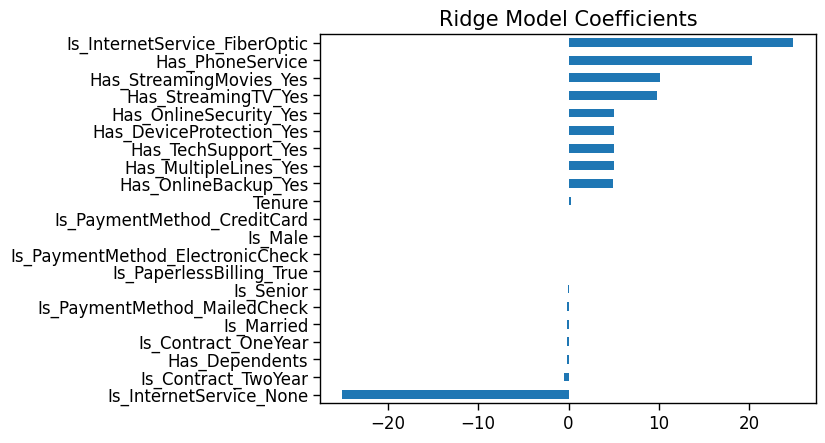

In [88]:
#Ridge Regression--------------------------------------------------------------
ridgeCV_model = RidgeCV(alphas=np.logspace(-6, 6, 13), scoring='r2', cv=10)
ridgeCV_model.fit(X_train, y_train)
optimal_alpha = ridgeCV_model.alpha_
#
ridge_regr = Ridge(alpha = optimal_alpha)
ridge_regr.fit(X_train, y_train)
y_pred = ridge_regr.predict(X_test)

print('r2 score (coefficient of determination): '+str(round(r2_score(y_test, y_pred),3)))
print('MAE : ' +str(round(mean_absolute_error(y_test, y_pred),3)))
print('alpha: ",optimal_alpha')
#
print('Model coefficients:', ridge_regr.coef_)
#extract the coefficients
coef_lasso = pd.DataFrame({"var": X_train.columns,
                           "coef":ridge_regr.coef_})

coef = pd.Series(ridge_regr.coef_, X_train.columns).sort_values()
coef.plot(kind='barh', title='Ridge Model Coefficients')
plt.show()


In [89]:
# Optional: create a new DataFrame named 'comparison' where you can combine/compare the actual and predicted values
# Create a new column 'y_actual' and set its values to the ones contained in y_test
# and another new column 'y_predicted' and set its values to the ones in y_pred
# Preview its results

comparison = pd.DataFrame([])
comparison['y_actual'] = y_test
comparison['y_predicted'] = y_pred
comparison.head()

,y_actual,y_predicted
185,24.80,24.579456
2715,24.30,25.443110
3825,19.84,19.530728
1807,76.35,74.866821
132,48.66,50.234821


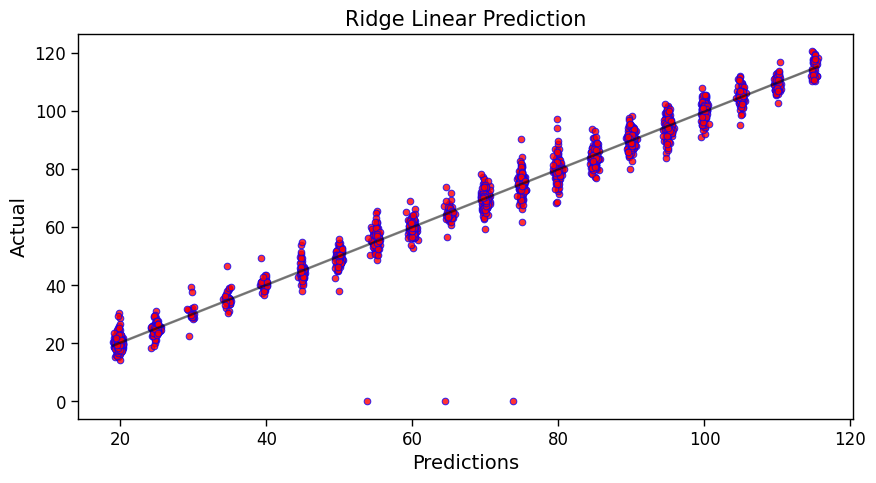

In [91]:
# Visualising the results in a regplot between y_pred and y_test.
# Pass as additional arguments
# scatter_kws={'color':'red','edgecolor':'blue', 'linewidths':0.7}
# and line_kws={'color':'black','alpha':0.5}

plt.figure(figsize=(10,5))
sns.regplot(x= y_pred, y = y_test,
            scatter_kws={'color':'red',
                         'edgecolor':'blue',
                         'linewidths':0.7},
            line_kws={'color':'black','alpha':0.5}
           )
plt.xlabel('Predictions')
plt.ylabel('Actual')
plt.title("Ridge Linear Prediction")
plt.show()

##Importances and Shapeley for XGBoost

In [ ]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

### Importances

/tmp/ipykernel_1335/3556346321.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(feature_scores.index, size = 10)


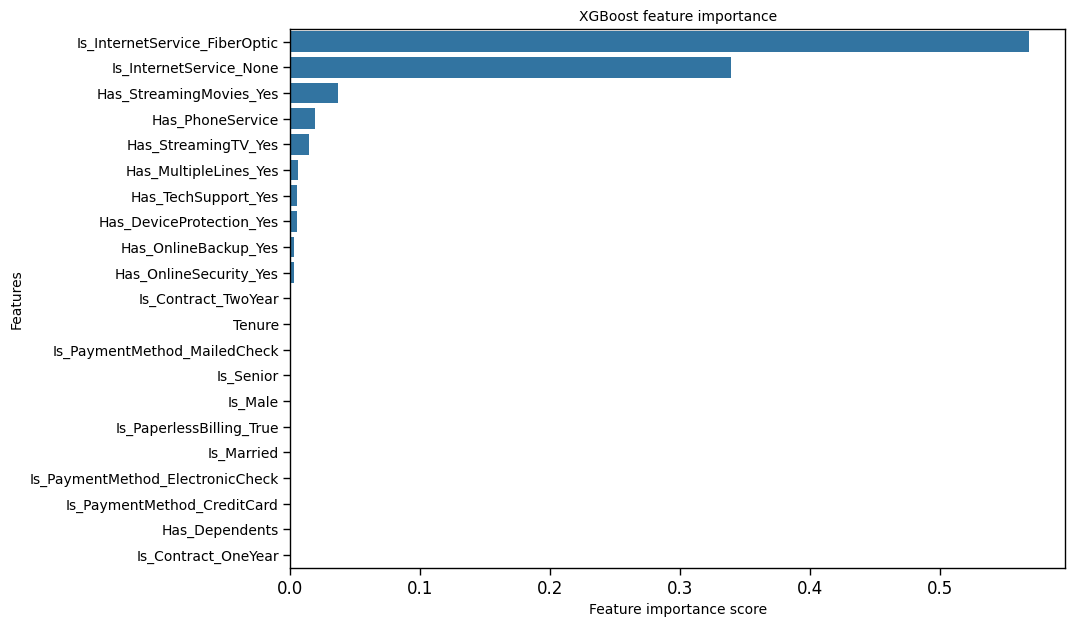

In [96]:
# Get the feature importance from the rf classifier using rf_opt.feature_importances_
# Cast it into a pd.DataFrame and use sort_values to sort by the importance

feature_scores = pd.DataFrame(xgb.feature_importances_, index=X_train.columns, columns=['Importance'])
feature_scores.sort_values(by='Importance', ascending=False, inplace=True)
#feature_scores.head(10)
#
# Plot the rf_opt.feature_importances_ in a barplot

f, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(x='Importance', y=feature_scores.index, data=feature_scores)
ax.set_title("XGRegressor feature importance", size = 10)
ax.set_yticklabels(feature_scores.index, size = 10)
ax.set_xlabel("Feature importance score", size = 10)
ax.set_ylabel("Features", size = 10)
plt.show()

# Run the models with a pipeline

In [60]:

# make pipeline and hyperparameters
models = {
    'Lasso': Lasso(random_state=42),
    'Ridge': Ridge(random_state=42),
    'ElNet':  ElasticNet(random_state=42),
    'RandomF': RandomForestRegressor(random_state=42)
}

# Hyperparameters
# Create all hyperparameters for each of the models
# *********** Note that you need to use the name as defined in the pipeline steps (above) followed by exactly two (!) underscores '__'
# and the name of the parameter you would like to tune. This is the way the pipeline recognizes the object each parameter corresponds to

lasso_hyperparameters = {
    'lasso__alpha' : [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
}
ridge_hyperparameters = {
     'ridge__alpha' : [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
}
elnet_hyperparameters = {
    'elasticnet__alpha' : [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000],
    'elasticnet__l1_ratio' : [0.1, 0.3, 0.5, 0.7, 0.9]
}
randomf_hyperparameters = {
    'randomforestregressor__n_estimators': [100, 200],
    'randomforestregressor__max_features': ['auto', 'sqrt', 0.33],
    'randomforestregressor__min_samples_leaf': [1, 3, 5, 10]
}

hyperparameters = {
    'lasso': lasso_hyperparameters,
    'ridge': ridge_hyperparameters,
    'enet':  elnet_hyperparameters,
    'rf':    randomf_hyperparameters
}